# Effet de la taille des classes sur les résultats scolaires — Analyse économétrique

## Introduction

Ce projet examine la relation entre la taille des classes (mesurée par le ratio élèves/enseignant) et les résultats scolaires des élèves, à partir de données sur 420 districts scolaires en Californie (dataset CASchools).

**Question de recherche** : la réduction du nombre d'élèves par enseignant améliore-t-elle les résultats aux tests scolaires ?

**Démarche** : après une phase d'exploration des données, plusieurs modèles de régression MCO sont estimés en ajoutant progressivement des variables de contrôle, afin d'isoler au mieux l'effet propre du ratio élèves/enseignant et de discuter les biais potentiels (notamment le biais de variable omise).

## I-Import et Préparation de la base de donnés

**Import des bibliothèques**

In [40]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

**importation de la base de données**


In [6]:
df = pd.read_csv("CASchools.csv")

**Afficher les 10 premières lignes**

In [7]:
df.head(10)

,rownames,district,school,county,grades,students,teachers,calworks,lunch,computer,expenditure,income,english,read,math
0,1,75119,Sunol Glen Unified,Alameda,KK-08,195,10.900000,0.510200,2.040800,67,6384.911133,22.690001,0.000000,691.599976,690.000000
1,2,61499,Manzanita Elementary,Butte,KK-08,240,11.150000,15.416700,47.916698,101,5099.380859,9.824000,4.583333,660.500000,661.900024
2,3,61549,Thermalito Union Elementary,Butte,KK-08,1550,82.900002,55.032299,76.322601,169,5501.954590,8.978000,30.000002,636.299988,650.900024
3,4,61457,Golden Feather Union Elementary,Butte,KK-08,243,14.000000,36.475399,77.049202,85,7101.831055,8.978000,0.000000,651.900024,643.500000
4,5,61523,Palermo Union Elementary,Butte,KK-08,1335,71.500000,33.108601,78.427002,171,5235.987793,9.080333,13.857677,641.799988,639.900024
5,6,62042,Burrel Union Elementary,Fresno,KK-08,137,6.400000,12.318800,86.956497,25,5580.146973,10.415000,12.408759,605.700012,605.400024
6,7,68536,Holt Union Elementary,San Joaquin,KK-08,195,10.000000,12.903200,94.623703,28,5253.331055,6.577000,68.717949,604.500000,609.000000
7,8,63834,Vineland Elementary,Kern,KK-08,888,42.500000,18.806299,100.000000,66,4565.746094,8.174000,46.959461,605.500000,612.500000
8,9,62331,Orange Center Elementary,Fresno,KK-08,379,19.000000,32.189999,93.139801,35,5355.548340,7.385000,30.079157,608.900024,616.099976
9,10,67306,Del Paso Heights Elementary,Sacramento,KK-06,2247,108.000000,78.994202,87.316399,0,5036.211426,11.613333,40.275921,611.900024,613.400024


**Pour connaitre le type de base de données**

In [8]:
type(df)

pandas.core.frame.DataFrame

**Afficher la taille de la base**

In [9]:
df.shape

(420, 15)

**Pour afficher le nom des colonnes**


In [10]:
df.columns

Index(['rownames', 'district', 'school', 'county', 'grades', 'students',
       'teachers', 'calworks', 'lunch', 'computer', 'expenditure', 'income',
       'english', 'read', 'math'],
      dtype='object')

**Connaitre le type des colonnes(les informations sur la bases de données)**


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     420 non-null    int64  
 1   district     420 non-null    int64  
 2   school       420 non-null    object 
 3   county       420 non-null    object 
 4   grades       420 non-null    object 
 5   students     420 non-null    int64  
 6   teachers     420 non-null    float64
 7   calworks     420 non-null    float64
 8   lunch        420 non-null    float64
 9   computer     420 non-null    int64  
 10  expenditure  420 non-null    float64
 11  income       420 non-null    float64
 12  english      420 non-null    float64
 13  read         420 non-null    float64
 14  math         420 non-null    float64
dtypes: float64(8), int64(4), object(3)
memory usage: 49.3+ KB


**Pour vérifier les doublons**

In [15]:
df.duplicated().sum()

0

**Pour vérifier les valeurs manquantes**

In [16]:
df.isna().sum()

rownames       0
district       0
school         0
county         0
grades         0
students       0
teachers       0
calworks       0
lunch          0
computer       0
expenditure    0
income         0
english        0
read           0
math           0
dtype: int64

**Pour vérifier les valeurs incohérentes de quelques variables**

In [17]:
df["lunch"].min(), df["lunch"].max()
df["english"].min(), df["english"].max()
df["calworks"].min(), df["calworks"].max()

(0.0, 78.99420166015625)

**Pour indiquer à python que la variable district est catégorielle**

In [18]:
df["district"]=df["district"].astype("category")

**Création d'un score moyen à partir des scores de lecture et de mathématiques** 

In [46]:
df["score"] = (df["read"] + df["math"]) / 2

**Créer le ratio élèves-enseignants**

In [32]:
df["student_teacher_ratio"] = df["students"] / df["teachers"]

## II-Statistiques descriptives de la bases de données 

In [33]:
df.describe()

,rownames,students,teachers,calworks,lunch,computer,expenditure,income,english,read,math,score,student_teacher_ratio
count,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,210.500000,2628.792857,129.067376,13.246042,44.705237,303.383333,5312.407541,15.316588,15.768155,654.970477,653.342619,654.156548,19.640425
std,121.387808,3913.104985,187.912679,11.454821,27.123381,441.341298,633.937053,7.225890,18.285927,20.107980,18.754202,19.053347,1.891812
min,1.000000,81.000000,4.850000,0.000000,0.000000,0.000000,3926.069580,5.335000,0.000000,604.500000,605.400024,605.550018,14.000000
25%,105.750000,379.000000,19.662499,4.395375,23.282200,46.000000,4906.180054,10.639000,1.940807,640.400024,639.375015,640.050003,18.582360
50%,210.500000,950.500000,48.564999,10.520450,41.750700,117.500000,5214.516602,13.727800,8.777634,655.750000,652.449982,654.449997,19.723209
75%,315.250000,3008.000000,146.350002,18.981350,66.864725,375.250000,5601.401367,17.629001,22.970003,668.725006,665.849991,666.662491,20.871814
max,420.000000,27176.000000,1429.000000,78.994202,100.000000,3324.000000,7711.506836,55.327999,85.539719,704.000000,709.500000,706.750000,25.800000


## III-Analyse exploratoire

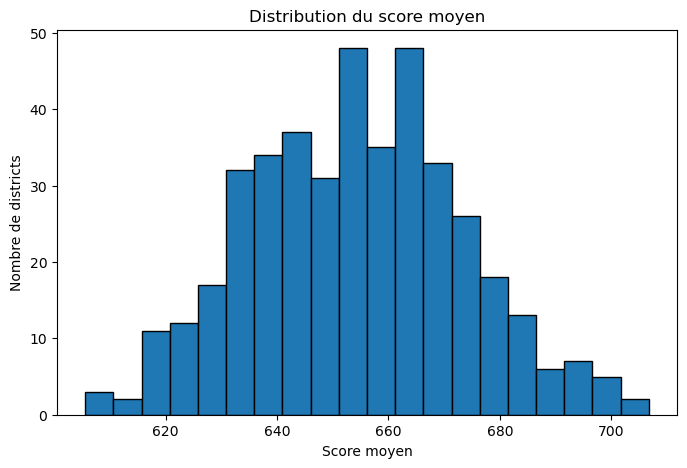

In [22]:
## visualisations des distributions de score
plt.figure(figsize=(8, 5))
plt.hist(df["score"].dropna(), bins=20, edgecolor="black")
plt.xlabel("Score moyen")
plt.ylabel("Nombre de districts")
plt.title("Distribution du score moyen")
plt.show()

on peut observer sur ce hisgrammes que la distributions des scores est majoritairement concentré entre 615 et 685

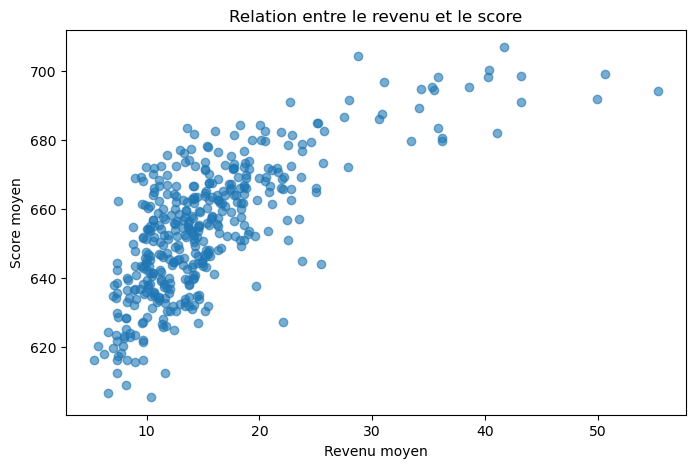

In [23]:
##visualisation su score et du revenu
plt.figure(figsize=(8, 5))
plt.scatter(df["income"], df["score"], alpha=0.6)
plt.xlabel("Revenu moyen")
plt.ylabel("Score moyen")
plt.title("Relation entre le revenu et le score")
plt.show()

ce graphique suggère une relation positive entre le score moyen et le revenu moyen, les districts aux revenus moyen élévés tendent à avoir un score moyen également élévés

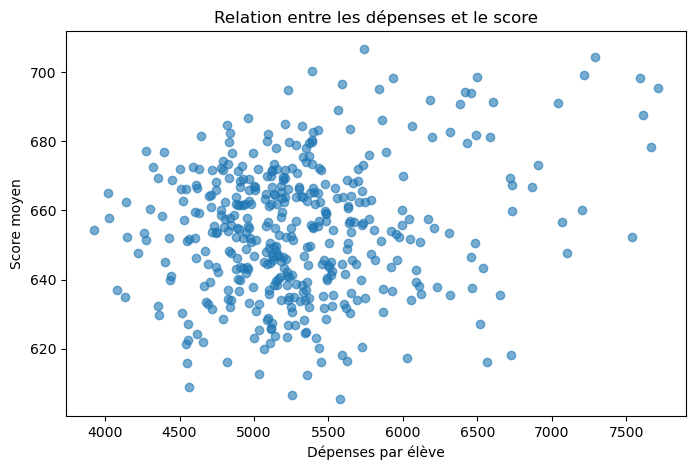

In [24]:
##visualisation du score et dépenses
plt.figure(figsize=(8, 5))
plt.scatter(df["expenditure"], df["score"], alpha=0.6)
plt.xlabel("Dépenses par élève")
plt.ylabel("Score moyen")
plt.title("Relation entre les dépenses et le score")
plt.show()

le graphique semble indiquer une faible relation positive entre les dépenses par élève et le score moyen. Étant donné qu'il y a une forte dispersion cette relation ne semble pas très marquée

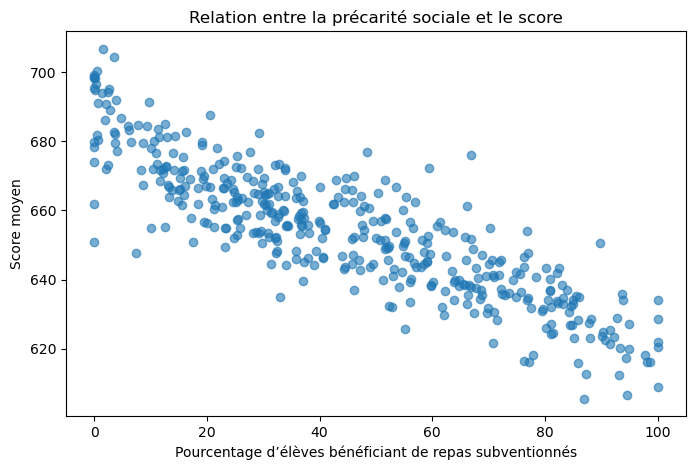

In [25]:
##score et repas subventionnés
plt.figure(figsize=(8, 5))
plt.scatter(df["lunch"], df["score"], alpha=0.6)
plt.xlabel("Pourcentage d’élèves bénéficiant de repas subventionnés")
plt.ylabel("Score moyen")
plt.title("Relation entre la précarité sociale et le score")
plt.show()

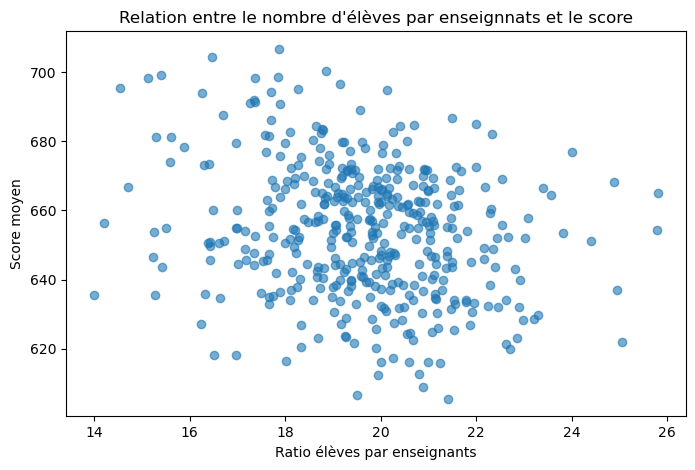

In [26]:
##distribution des score et ratio_élèves_enseignants
plt.figure(figsize=(8, 5))
plt.scatter(df["student_teacher_ratio"], df["score"], alpha=0.6)
plt.xlabel("Ratio élèves par enseignants")
plt.ylabel("Score moyen")
plt.title("Relation entre le nombre d'élèves par enseignnats et le score")
plt.show()

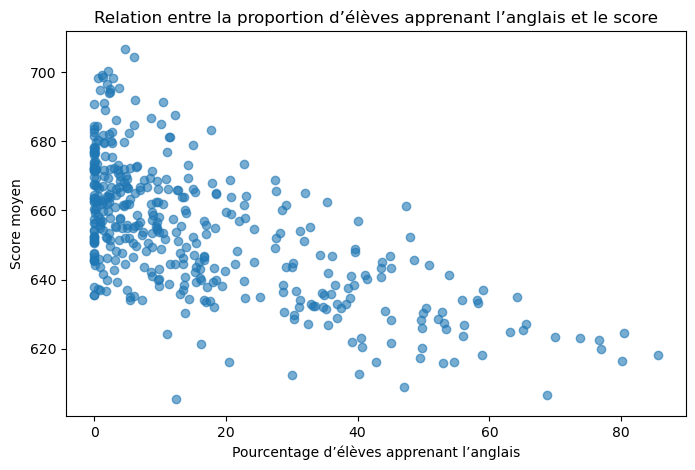

In [27]:
##score et élèves apprenant l'anglais
plt.figure(figsize=(8, 5))
plt.scatter(df["english"], df["score"], alpha=0.6)
plt.xlabel("Pourcentage d’élèves apprenant l’anglais")
plt.ylabel("Score moyen")
plt.title("Relation entre la proportion d’élèves apprenant l’anglais et le score")
plt.show()

In [52]:
#tableau de correlation
variables_correlation = [
    "score",
    "income",
    "expenditure",
    "lunch",
    "english",
    "student_teacher_ratio"
]

correlations = df[variables_correlation].corr()

correlations

,score,income,expenditure,lunch,english,student_teacher_ratio
score,1.000000,0.712431,0.191273,-0.868772,-0.644124,-0.226363
income,0.712431,1.000000,0.314484,-0.684440,-0.307419,-0.232194
expenditure,0.191273,0.314484,1.000000,-0.061039,-0.071396,-0.619982
lunch,-0.868772,-0.684440,-0.061039,1.000000,0.653061,0.135203
english,-0.644124,-0.307419,-0.071396,0.653061,1.000000,0.187642
student_teacher_ratio,-0.226363,-0.232194,-0.619982,0.135203,0.187642,1.000000


In [29]:
df.columns

Index(['rownames', 'district', 'school', 'county', 'grades', 'students',
       'teachers', 'calworks', 'lunch', 'computer', 'expenditure', 'income',
       'english', 'read', 'math', 'score', 'student_teacher_ratio'],
      dtype='object')

# IV-Analyses économétriques

**1-Modèle de régression simple**

In [30]:
mrs = smf.ols('score ~ student_teacher_ratio', data =df).fit()
print(mrs.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     22.58
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           2.78e-06
Time:                        15:07:38   Log-Likelihood:                -1822.2
No. Observations:                 420   AIC:                             3648.
Df Residuals:                     418   BIC:                             3657.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               698.93

En se basant sur le coefficient du modèle simple, lorsque le nombre d'élèves par enseignant augmente d'une unité, les résultats scolaires diminuent de 2,28 unités environs. La p-value est inférieur à 0,05 donc le coefficient est statistiquement fiable. le R² ajusté étant de 0,049 le modèle ne permet d'expliquer que 4,9% de la variance de la variable dépendante(score) ce qui est très faible, et qui laisse comprendre que la majorité de la variation des résultats scolaires n'est pas captée par le ratio élèves/enseignents. Pour mieux expliquer la variable dépendante il faudra rajouter d'autres variables explicatives afin de mieux estimer cet effet causal.


**2-Premier modèle de régression multiple (rajouter lunch au modèle)**

In [35]:
rm_1 = smf.ols('score ~ student_teacher_ratio + lunch', data=df).fit()
print(rm_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     685.8
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          1.43e-132
Time:                        15:34:21   Log-Likelihood:                -1527.5
No. Observations:                 420   AIC:                             3061.
Df Residuals:                     417   BIC:                             3073.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               702.91

lorsque le nombre d'élèves par enseignant augmente d'une unité, les résultats scolaires diminuent de 1,12 unités ceterus paribus. La p-value est inférieur à 0,05 donc le coefficient est statistiquement fiable. Le R² ajusté est de 0,766 le modèle permet d'expliquer 76,6% de la variance de la variable expliqué ce qui est très bien. 

D'après la matrice de correlation,  la variable lunch étant corrélé positivement avec str(les districs pauvres ont des classes plus chargées) et négativement avec le score ; ansi le modèle simple ne captait qu'une partie  de l'effet de la pauvreté sans le savoir ce qui sur-estimait l'effet de str raison pour laquelle le coefficient passe de -2,28 dans le modèle simple à -1,12 dans le modèle multiple.  

On peut en déduire que la variable lunch est très importante pour bien capter l'effet causal entre le ratio élèves/enseignants et le score des résultats des élèves, et son abscence dans le modèle simple traduit un biais de variable omise.

**3-Deuxième modèle de régression multiple (rajouter english)**

In [36]:
rm_2= smf.ols('score ~ student_teacher_ratio + lunch + english', data=df).fit()
print(rm_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     476.3
Date:                Sat, 15 Aug 2026   Prob (F-statistic):          4.03e-134
Time:                        14:52:30   Log-Likelihood:                -1520.5
No. Observations:                 420   AIC:                             3049.
Df Residuals:                     416   BIC:                             3065.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               700.15

Lorsque le nombre d'élèves par enseignant augmente d'une unité, les résultats scolaires diminuent de 0,9983 unité, ceteris paribus. La p-value est inférieure à 0,05, donc le coefficient est statistiquement fiable. Le R² ajusté est de 0,773 : le modèle explique 77,3% de la variance de la variable expliquée, ce qui est légèrement mieux que le modèle 2.

D'après la matrice de corrélation, la variable english est corrélée positivement, mais faiblement, avec str (les districts avec une plus forte proportion d'élèves apprenant l'anglais comme langue seconde ont tendance à avoir des classes légèrement plus chargées) et négativement avec score. Ainsi, en l'absence de cette variable, le modèle 2 attribuait à str une partie de l'effet réellement dû à english, ce qui surestimait encore légèrement son effet d'où le passage du coefficient de -1,12 à -1,00 entre les deux modèles.

On peut en déduire que l'ajout de la variable english permet d'obtenir une estimation plus précise et moins biaisée de l'effet causal du ratio élèves/enseignant sur les résultats scolaires, en contrôlant pour un facteur supplémentaire lié à la composition démographique des élèves.

## V-Discussion critiques et limites 

**1-Synthèse comparative des trois modèles**

On remarque que l'effet de str diminue en valeur absolue à chaque ajout de variable de contrôle (de -2,28 à -1,00), ce qui confirme la présence d'un biais de variable omise dans le modèle simple.

En ce qui concerne la qualité d'ajustement du modèle, l'écart le plus important survient entre le modèle 1 et le modèle 2, grâce à l'ajout de la variable lunch, qui s'avère être le contrôle le plus déterminant. La variable english, quant à elle, n'apporte qu'un gain marginal en termes de R² ajusté.

Malgré ces contrôles, l'effet de str reste négatif et statistiquement significatif dans les trois modèles, ce qui constitue un argument empirique en faveur d'un lien entre la taille des classes et les résultats scolaires. 

**2-Limites**

Malgré les contrôles ajoutés, l'estimation reste exposée à un biais de variable omise résiduel : des facteurs non observés comme la qualité des enseignants ou l'implication des familles peuvent influencer à la fois le ratio élèves/enseignant et les résultats scolaires. Une approche par variable instrumentale permettrait de renforcer l'identification causale, mais dépasse le cadre de cette analyse.

## Conclusion
Cette analyse met en évidence une relation négative et statistiquement significative entre le ratio élèves/enseignant et les résultats scolaires, qui persiste après contrôle pour la pauvreté et la composition démographique des élèves. Si cette relation ne peut être qualifiée de pleinement causale, elle constitue un argument empirique en faveur d'un effet de la taille des classes sur la réussite scolaire, avec des implications potentielles pour les politiques éducatives visant à réduire les effectifs par classe.